<a href="https://colab.research.google.com/github/HowardChen0211/gisPy/blob/main/ProblemSets_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProblemSet 0



## Research Question:

- Which cities in California are the most livable, and what social, economic, and environmental factors explain the differences between them?


## Unit of Analysis
Incorporated city in California (n = 482), filtered the data to exclude Census Designated Places (more than 1,100)

#### Install the package (If needed)

In [80]:
# !pip install geopandas
# !pip install mapclassify

#### Import the package from library

In [81]:
import os, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd # gis/maps

import mapclassify # need for thematic map classification

# will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#### Load the dataset
These datasets contain shapefile boundaries for CA State, counties and places from the US Census Bureau's 2023 MAF/TIGER database

In [82]:
# The CA Boundaries data can be found at here https://catalog.data.gov/dataset/ca-geographic-boundaries

# -q = quiet; -O = output filename; saves file as CA_Counties_Boundaries.zip

# CA Counties Boundary dataset
! wget -q -O CA_Counties_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/b0007416-a325-4777-9295-368ea6b710e6/download/ca_counties.zip

# CA State Boundary dataset
! wget -q -O CA_State_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/3db1e426-fb51-44f5-82d5-a54d7c6e188b/download/ca_state.zip

# CA Places Boundary dataset
! wget -q -O CA_Places_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/436fc714-831c-4070-b44b-b06dcde6bf18/download/ca_places.zip

In [83]:
# Unzip the file
# zip_ref = zipfile.ZipFile('CA_Counties_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()
# zip_ref = zipfile.ZipFile('CA_State_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()
# zip_ref = zipfile.ZipFile('CA_Places_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()

In [84]:
for z in ["CA_Counties_Boundaries.zip", "CA_State_Boundaries.zip", "CA_Places_Boundaries.zip"]:
  with zipfile.ZipFile(z, 'r') as zf:
    zf.extractall()

!ls # see what we got

CA_Counties_Boundaries.zip  CA_Places.cpg	     CA_State.dbf
CA_Counties.cpg		    CA_Places.dbf	     CA_State.prj
CA_Counties.dbf		    CA_Places.prj	     CA_State.sbn
CA_Counties.prj		    CA_Places.sbn	     CA_State.sbx
CA_Counties.sbn		    CA_Places.sbx	     CA_State.shp
CA_Counties.sbx		    CA_Places.shp	     CA_State.shp.xml
CA_Counties.shp		    CA_Places.shp.xml	     CA_State.shx
CA_Counties.shp.xml	    CA_Places.shx	     drive
CA_Counties.shx		    CA_State_Boundaries.zip  sample_data
CA_Places_Boundaries.zip    CA_State.cpg


### State Boundary

In [85]:
state = gpd.read_file('CA_State.shp') # load the shapefile with gpd as ca_state
state.head() # see the first 5 rows

,OBJECTID,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,56,4,9,06,01779778,06,CA,California,00,G4000,A,4.034672e+11,2.049980e+10,+37.1551773,-119.5434183,5.258041e+06,5.258041e+06,6.718927e+11,"MULTIPOLYGON (((-13060108.516 3854208.959, -13..."


In [86]:
state.dtypes # see the data types

,0
OBJECTID,int64
REGION,object
DIVISION,object
STATEFP,object
STATENS,object
GEOID,object
STUSPS,object
NAME,object
LSAD,object
MTFCC,object


In [87]:
state.shape # see the size of the data (1 rows, 19 columns)

(1, 19)

<Axes: >

Text(0.5, 1.0, 'California, State Boundary')

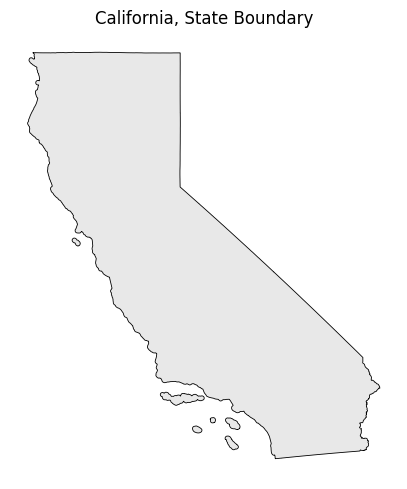

In [88]:
fig, ax = plt.subplots(figsize=(5, 6))
state.plot(ax=ax, color="#e8e8e8", edgecolor="black", linewidth=0.6)
ax.set_title("California, State Boundary")
ax.set_axis_off()
plt.show()

As you can see, it shows the state of California

### Counties Boundary




In [89]:
ca_counties = gpd.read_file('CA_Counties.shp') # load the shapefile with gpd as ca_counties

In [90]:
ca_counties.head() # see the first 5 rows

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,06,091,00277310,06091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,2.468695e+09,2.329911e+07,+39.5769252,-120.5219926,375602.758281,4.200450e+09,"POLYGON ((-13431319.751 4821511.426, -13431312..."
1,06,067,00277298,06067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,2.499984e+09,7.542543e+07,+38.4500161,-121.3404408,406584.174167,4.205516e+09,"POLYGON ((-13490651.476 4680831.603, -13490511..."
2,06,083,00277306,06083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,7.084063e+09,2.729752e+09,+34.5370572,-120.0399729,891686.747247,1.449841e+10,"MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,06,009,01675885,06009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,2.641785e+09,4.384187e+07,+38.1838996,-120.5614415,367005.879680,4.356213e+09,"POLYGON ((-13428575.483 4627725.227, -13428534..."
4,06,111,00277320,06111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,4.771988e+09,9.473454e+08,+34.3587415,-119.1331432,527772.242190,8.413293e+09,"MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


In [91]:
ca_counties.dtypes # see the data types

,0
STATEFP,object
COUNTYFP,object
COUNTYNS,object
GEOID,object
NAME,object
NAMELSAD,object
LSAD,object
CLASSFP,object
MTFCC,object
CSAFP,object


In [92]:
# Check how many features (20)
print(ca_counties.columns)

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')


In [93]:
# Select the column I need
cols = ["GEOID", "NAME", "NAMELSAD", "ALAND", "AWATER", "geometry"]
counties = ca_counties[cols].copy() # don't alter the original data

print("Dimensions:", counties.shape)
counties.head()

Dimensions: (58, 6)


,GEOID,NAME,NAMELSAD,ALAND,AWATER,geometry
0,06091,Sierra,Sierra County,2.468695e+09,2.329911e+07,"POLYGON ((-13431319.751 4821511.426, -13431312..."
1,06067,Sacramento,Sacramento County,2.499984e+09,7.542543e+07,"POLYGON ((-13490651.476 4680831.603, -13490511..."
2,06083,Santa Barbara,Santa Barbara County,7.084063e+09,2.729752e+09,"MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,06009,Calaveras,Calaveras County,2.641785e+09,4.384187e+07,"POLYGON ((-13428575.483 4627725.227, -13428534..."
4,06111,Ventura,Ventura County,4.771988e+09,9.473454e+08,"MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


<Axes: >

Text(0.5, 1.0, 'California, 58 counties')

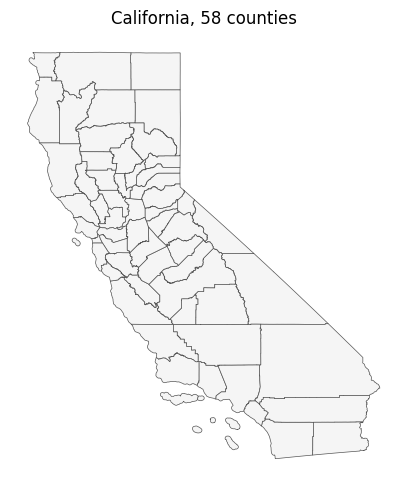

In [94]:
fig, ax = plt.subplots(figsize=(5, 6))
counties.plot(ax=ax, color="#f5f5f5", edgecolor="#555555", linewidth=0.5)
ax.set_title("California, 58 counties")
ax.set_axis_off()
plt.show()

As you can see, it shows 58 counties boundary of California

### Cities Boundary

In [95]:
ca_places = gpd.read_file('CA_Places.shp') # load the shapefile with gpd as ca_places

ca_places.shape # see the size of the data (1521 rows, 19 columns)

(1521, 19)

In [96]:
ca_places.dtypes # see the data types

,0
STATEFP,object
PLACEFP,object
PLACENS,object
GEOID,object
NAME,object
NAMELSAD,object
LSAD,object
CLASSFP,object
PCICBSA,object
PCINECTA,object


In [97]:
ca_places[["NAME", "NAMELSAD", "CLASSFP", "FUNCSTAT"]].head()

,NAME,NAMELSAD,CLASSFP,FUNCSTAT
0,San Fernando,San Fernando city,C1,A
1,Cloverdale,Cloverdale city,C1,A
2,Cotati,Cotati city,C1,A
3,San Buenaventura (Ventura),San Buenaventura (Ventura) city,C1,A
4,Glendora,Glendora city,C1,A


In [98]:
# Using mask method to filter the cities that is incorporated city
mask = (ca_places["CLASSFP"].str.startswith("C", na=False)
        & (ca_places["FUNCSTAT"] == "A"))

cols = ["GEOID", "NAME", "NAMELSAD", "CLASSFP", "ALAND", "AWATER", "geometry"]
cities = ca_places.loc[mask, cols].copy()

print("Dimensions:", cities.shape) # Reduced from 1,521 to 482 incorporated cities
cities.head()

Dimensions: (482, 7)


,GEOID,NAME,NAMELSAD,CLASSFP,ALAND,AWATER,geometry
0,0666140,San Fernando,San Fernando city,C1,6148696.0,0.0,"POLYGON ((-13186463.855 4067122.651, -13186256..."
1,0614190,Cloverdale,Cloverdale city,C1,8107251.0,0.0,"POLYGON ((-13696207.846 4691208.338, -13696205..."
2,0616560,Cotati,Cotati city,C1,4869301.0,8380.0,"POLYGON ((-13662197.838 4626644.613, -13662188..."
3,0665042,San Buenaventura (Ventura),San Buenaventura (Ventura) city,C1,56675175.0,26959120.0,"MULTIPOLYGON (((-13280094.138 4075172.878, -13..."
4,0630014,Glendora,Glendora city,C1,50527933.0,400123.0,"POLYGON ((-13123461.909 4048524.147, -13123461..."


<Axes: >

Text(0.5, 1.0, 'California, 482 incorporated cities')

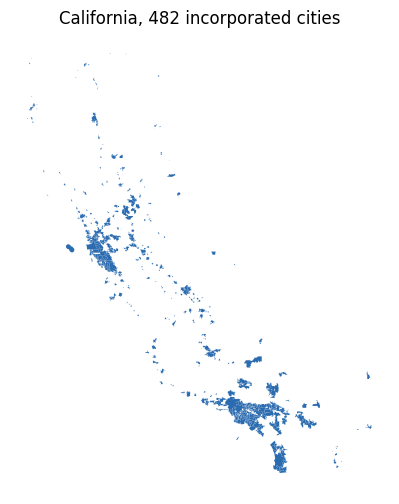

In [99]:
fig, ax = plt.subplots(figsize=(5, 6))
cities.plot(ax=ax, color="#2b6cb0", linewidth=0)
ax.set_title("California, 482 incorporated cities")
ax.set_axis_off()
plt.show()

As you can see, it shows the places of Californiac excluding the Census Designated Places.
And there are three dense clusters(the Bay Area, the Los Angeles basin, and the San Diego coast)

# ProblemSet 1

### Layered Map - Combine States, Counties, Cities

<Axes: >

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Incorporated cities within California counties, 2023')

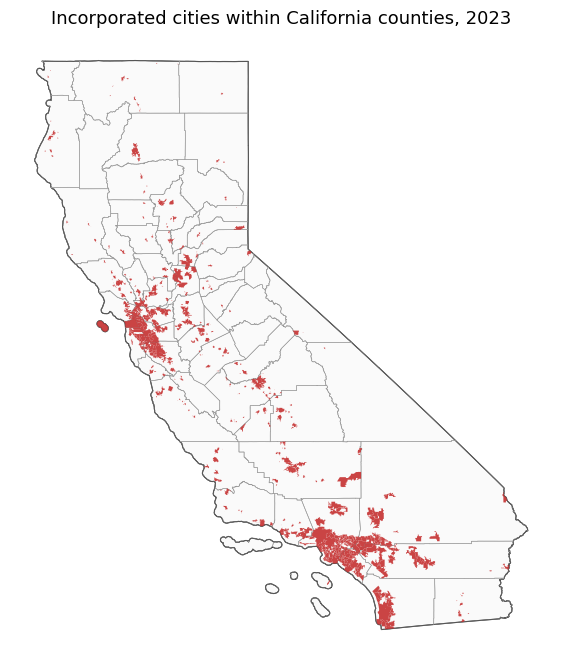

In [100]:
fig, ax = plt.subplots(figsize=(7, 9))

state.plot(ax=ax, color="#fafafa", edgecolor="black", linewidth=0.8)
counties.plot(ax=ax, color="none", edgecolor="#999999", linewidth=0.4)
cities.plot(ax=ax, color="#c53030", linewidth=0, alpha=0.9)

ax.set_title("Incorporated cities within California counties, 2023", fontsize=13)
ax.set_axis_off()
plt.show()

### Join the ACS(American Community Survey) data

## Reference
1. Designated Cities: https://en.wikipedia.org/wiki/List_of_census-designated_places_in_California

2. Municipalities: https://en.wikipedia.org/wiki/List_of_municipalities_in_California

3. Counties: https://en.wikipedia.org/wiki/List_of_counties_in_California